In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
df= sns.load_dataset('iris')

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

In [7]:
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
42,4.4,3.2,1.3,0.2,0
100,6.3,3.3,6.0,2.5,2
109,7.2,3.6,6.1,2.5,2
22,4.6,3.6,1.0,0.2,0
44,5.1,3.8,1.9,0.4,0


In [9]:
df = df[['sepal_length', 'petal_length', 'species']]

In [10]:
df.head()

,sepal_length,petal_length,species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0


In [11]:
X = df.iloc[:, 0:2]
y = df.iloc[:,-1]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [13]:
X_train.head()

,sepal_length,petal_length
126,6.2,4.8
23,5.1,1.7
64,5.6,3.6
117,7.7,6.7
84,5.4,4.5


In [14]:
clf = LogisticRegression(multi_class='multinomial')

In [15]:
clf.fit(X_train, y_train)

C:\Users\Rafy Mustafa\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial')

In [16]:
y_pred = clf.predict(X_test)

In [17]:
accuracy_score(y_test, y_pred)

0.9666666666666667

In [19]:
pd.DataFrame(confusion_matrix(y_test, y_pred))

,0,1,2
0,14,0,0
1,0,7,1
2,0,0,8


In [22]:
# prediction
query = np.array([[3.4, 2.7]])
clf.predict_proba(query) # predict probability function

C:\Users\Rafy Mustafa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[7.25865651e-01, 2.73720718e-01, 4.13631316e-04]])

In [23]:
clf.predict(query)

C:\Users\Rafy Mustafa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [28]:
!pip install mlxtend

C:\Users\Rafy Mustafa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


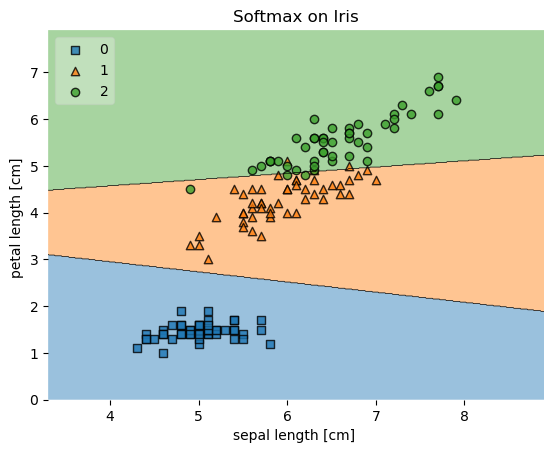

In [30]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values, y.values, clf, legend=2)

# Adding axis anotation
plt.xlabel('sepal length [cm] ')
plt.ylabel('petal length [cm] ')
plt.title('Softmax on Iris')

plt.show()
